In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [2]:
!kaggle datasets download -d jangedoo/utkface-new

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
 78% 258M/331M [00:00<00:00, 642MB/s] 
100% 331M/331M [00:00<00:00, 655MB/s]


In [3]:
from zipfile import ZipFile
zip_ref = ZipFile('/content/utkface-new.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [6]:
import numpy as np
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
dataset_folder_name = r'/content/UTKFace'
TRAIN_TEST_SPLIT = 0.7
IM_WIDTH = IM_HEIGHT = 198

dataset_dict = {
    'race_id': {
        0: 'white',
        1: 'black',
        2: 'asian',
        3: 'indian',
        4: 'others'
    },
    'gender_id': {
        0: 'male',
        1: 'female'
    }
}
dataset_dict['gender_alias'] = dict((g,i) for i, g in dataset_dict['gender_id'].items())
dataset_dict['race_alias'] = dict((r,i) for i, r in dataset_dict['race_id'].items())

In [7]:
def parse_dataset(dataset_path, ext='jpg'):
    """
    Used to extract information about our dataset. It does iterate
    over all images and return a DataFrame with the data (age, gender
    and sex) of all files
    """
    def parse_info_from_file(path):
        """
        Parse information from a single file
        """
        try:
            filename = os.path.split(path)[1]
            filename = os.path.splitext(filename)[0]
            age, gender, race, _ = filename.split('_')

            return int(age), dataset_dict['gender_id'][int(gender)], dataset_dict['race_id'][int(race)]
        except Exception as ex:
            return None, None, None

    files = glob.glob(os.path.join(dataset_path, f"*.{ext}"))

    records = []
    for file in files:
        info = parse_info_from_file(file)
        records.append(info)

    df = pd.DataFrame(records)
    df['file'] = files
    df.columns = ['age', 'gender', 'race', 'file']
    df = df.dropna()

    return df

df = parse_dataset(dataset_folder_name)
df.head()


,age,gender,race,file
0,3.0,male,others,/content/UTKFace/3_0_4_20161221200453808.jpg.c...
1,27.0,female,asian,/content/UTKFace/27_1_2_20170104020523491.jpg....
2,2.0,male,asian,/content/UTKFace/2_0_2_20161219160916782.jpg.c...
3,26.0,female,white,/content/UTKFace/26_1_0_20170116234619701.jpg....
4,1.0,female,white,/content/UTKFace/1_1_0_20161219190725427.jpg.c...


In [8]:
import plotly.graph_objects as go

def plot_distribution(pd_series):
    labels = pd_series.value_counts().index.tolist()
    counts = pd_series.value_counts().values.tolist()

    pie_plot = go.Pie(labels=labels, values=counts, hole=.3)
    fig = go.Figure(data=[pie_plot])
    fig.update_layout(title_text='Distribution for %s' % pd_series.name)

    fig.show()

In [9]:
plot_distribution(df['race'])

In [10]:
plot_distribution(df['gender'])

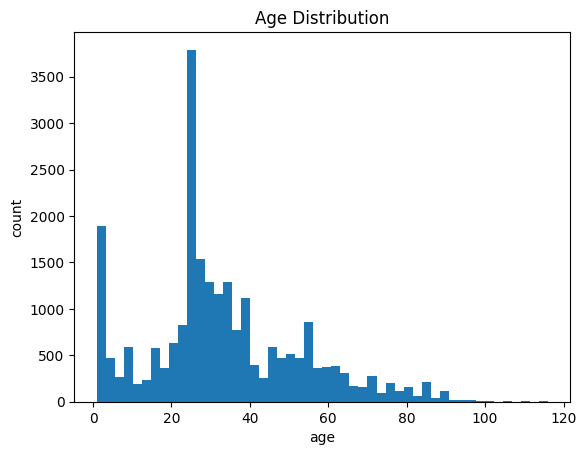

In [11]:
plt.hist(df['age'], bins=50)
plt.title('Age Distribution')
plt.xlabel('age')
plt.ylabel('count')
plt.show()

In [12]:
bins = [0,10,20,30,40,60,80,np.inf]
names = ['<10','10-20','20-30','30-40','40-60','60-80','80+']

age_binned = pd.cut(df['age'], bins, labels=names)
plot_distribution(age_binned)

In [13]:
from keras.utils import to_categorical
from PIL import Image

class UTKFaceDataGenerator():
    """
    Data generator for the UTKFace dataset. This class should be used when training
    our keras multi-output model.
    """
    def __init__(self, df):
        self.df = df

    def generate_split_indexes(self):
        p = np.random.permutation(len(self.df))
        train_up_to = int(len(self.df)*TRAIN_TEST_SPLIT)
        train_idx = p[:train_up_to]
        test_idx = p[train_up_to:]

        train_up_to = int(train_up_to *TRAIN_TEST_SPLIT)
        train_idx, valid_idx = train_idx[:train_up_to], train_idx[train_up_to:]

        # converts alias to id
        self.df['gender_id'] = self.df['gender'].map(lambda gender:dataset_dict['gender_alias'][gender])
        self.df['race_id'] = self.df['race'].map(lambda race:dataset_dict['race_alias'][race])

        self.max_age = self.df['age'].max()

        return train_idx, valid_idx, test_idx

    def preprocess_image(self, img_path):
        """
        Used to perform some minor preprocessing on the image brfore inputting
        into the network
        """
        im = Image.open(img_path)
        im = im.resize((IM_WIDTH, IM_HEIGHT))
        im = np.array(im) / 255

        return im

    def generates_images(self, image_idx, is_training, batch_size=16):
        """
        Used to generate a batch with images when training/testing/validating
        our keras model.
        """
        #arrays to store our batched data
        images, ages, races, genders = [],[],[],[]
        while True:
            for idx in image_idx:
                person = self.df.iloc[idx]

                age = person['age']
                race = person['race_id']
                gender = person['gender_id']
                file = person['file']

                im = self.preprocess_image(file)

                ages.append(age/self.max_age)
                races.append(to_categorical(race, len(dataset_dict['race_id'])))
                genders.append(to_categorical(gender, len(dataset_dict['gender_id'])))
                images.append(im)

                # yielding condition
                if len(images) >= batch_size:
                    yield np.array(images), (np.array(ages), np.array(races), np.array(genders))
                    images, ages, races, genders = [], [], [], []

            if not is_training:
                break;

data_generator = UTKFaceDataGenerator(df)
train_idx, valid_idx, test_idx = data_generator.generate_split_indexes()

In [14]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Model
from keras.layers import BatchNormalization
from keras.layers import Dense, Flatten, Dropout, Input, Lambda
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D

In [15]:
class UtkMultiOutputModel():

    def make_default_hidden_layers(self, inputs):
        x = Conv2D(16, (3,3), padding='same', activation='relu')(inputs)
        x = BatchNormalization()(x)
        x = MaxPooling2D(pool_size=(3,3))(x)
        x = Dropout(0.25)(x)

        x = Conv2D(16, (3,3), padding='same', activation='relu')(inputs)
        x = BatchNormalization()(x)
        x = MaxPooling2D(pool_size=(2,2))(x)
        x = Dropout(0.25)(x)

        x = Conv2D(16, (3,3), padding='same', activation='relu')(inputs)
        x = BatchNormalization()(x)
        x = MaxPooling2D(pool_size=(2,2))(x)
        x = Dropout(0.25)(x)

        return x

    def build_race_branch(self, inputs, num_races):
        x = self.make_default_hidden_layers(inputs)

        x = Flatten()(x)
        x = Dense(128, activation='relu')(x)
        x = BatchNormalization()(x)
        x = Dropout(0.5)(x)
        x = Dense(num_races, activation='softmax', name='race_output')(x)

        return x

    def build_age_branch(self, inputs):
        x = self.make_default_hidden_layers(inputs)

        x = Flatten()(x)
        x = Dense(128, activation='relu')(x)
        x = BatchNormalization()(x)
        x = Dropout(0.5)(x)
        x = Dense(1, activation='linear', name='age_output')(x)

        return x

    def build_gender_branch(self, inputs, num_genders=2):
        x = Lambda(lambda c: tf.image.rgb_to_grayscale(c))(inputs)

        x = self.make_default_hidden_layers(inputs)

        x = Flatten()(x)
        x = Dense(128, activation='relu')(x)
        x = BatchNormalization()(x)
        x = Dropout(0.5)(x)
        x = Dense(num_genders, activation='sigmoid', name='gender_output')(x)

        return x

    def assemble_full_model(self, width, height, num_races):
        input_shape = (height, width, 3)

        inputs = Input(shape=input_shape)

        age_branch = self.build_age_branch(inputs)
        race_branch = self.build_race_branch(inputs, num_races)
        gender_branch = self.build_gender_branch(inputs)

        model = Model(inputs=inputs, outputs=[age_branch, race_branch, gender_branch], name="face_net")
        return model

model = UtkMultiOutputModel().assemble_full_model(IM_WIDTH, IM_HEIGHT, num_races=len(dataset_dict['race_alias']))

In [16]:
init_lr = 1e-4
epochs = 100

opt = keras.optimizers.Adam(learning_rate=init_lr, decay=init_lr/epochs)

model.compile(optimizer=opt,
             loss={
                 'age_output': 'mse',
                 'race_output': 'categorical_crossentropy',
                 'gender_output': 'binary_crossentropy'
             },
             loss_weights={
                 'age_output': 4.,
                 'race_output': 1.5,
                 'gender_output': 0.1
             },
             metrics={
                 'age_output': 'mae',
                 'race_output': 'accuracy',
                 'gender_output': 'accuracy'
             }
)

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning:

Argument `decay` is no longer supported and will be ignored.



In [18]:
from keras.callbacks import ModelCheckpoint

batch_size = 32
valid_batch_size = 32
train_gen = data_generator.generates_images(train_idx, is_training=False, batch_size=batch_size)
valid_gen = data_generator.generates_images(valid_idx, is_training=False, batch_size=batch_size)

# callbacks = [ModelCheckpoint("./model_checkpoint", monitor='val_loss')]

history = model.fit(train_gen, steps_per_epoch=len(train_idx)//batch_size, epochs=epochs,
                    validation_data=valid_gen,validation_steps=len(valid_idx)//valid_batch_size,)

Epoch 1/100
 14/362 ━━━━━━━━━━━━━━━━━━━━ 24:38 4s/step - age_output_loss: 4.0782 - age_output_mae: 1.5286 - gender_output_accuracy: 0.6834 - gender_output_loss: 0.7460 - loss: 18.8632 - race_output_accuracy: 0.4221 - race_output_loss: 1.6506

KeyboardInterrupt: 

In [ ]:
model